# 06 — Final Evaluation & Comparison

**Goal:** Produce the definitive comparison table and figures across all approaches.

| Method | Type | Evaluated on |
|--------|------|--------------|
| LastValue baseline | Naive | All game sessions |
| RollingMean(10) | Naive | All game sessions |
| SessionMean | Naive | All game sessions |
| LightGBM (walk-forward) | Supervised | Held-out subsessions |
| Non-RL Greedy Policy | Supervised + Policy | All game sessions |
| LinUCB Bandit | RL | Offline IPS estimate |
| FQI Q-learning | RL | Offline IPS estimate |

In [1]:
import sys, json, warnings, pickle
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from baselines import compare_baselines

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
OUTPUTS_DIR   = Path('../outputs')
FIGURES_DIR   = Path('../outputs/figures')

meta         = json.loads((PROCESSED_DIR/'feature_meta.json').read_text())
TARGET       = meta['target']
TARGET_NEXT  = meta['target_next']
FEATURE_COLS = meta['feature_cols']
ACTION_MAP   = meta['action_map']
SS_COL       = 'subsession'

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.labelcolor':'#e6edf3','xtick.color':'#8b949e',
    'ytick.color':'#8b949e','text.color':'#e6edf3',
    'grid.color':'#21262d','grid.linestyle':'--','font.family':'monospace'
})
print('Setup complete.')

Setup complete.


## 1. Load All Results

In [2]:
df_feat = pd.read_parquet(PROCESSED_DIR/'features.parquet')
df_game = df_feat[df_feat[SS_COL]>0].copy()

# Load saved model
with open(OUTPUTS_DIR/'lgbm_predictor.pkl','rb') as f:
    lgbm_saved = pickle.load(f)
lgbm_model  = lgbm_saved['model']
cv_metrics  = pd.DataFrame(lgbm_saved['cv_metrics'])

print(f'Loaded LGBM model. CV folds: {len(cv_metrics)}')
print(f'Game data: {len(df_game):,} rows')

Loaded LGBM model. CV folds: 8
Game data: 2,712 rows


## 2. Prediction Metrics Comparison

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from baselines import compare_baselines

# Baselines
bl_table = compare_baselines(df_game)

# LightGBM (walk-forward CV mean)
lgbm_row = pd.DataFrame([{
    'MAE':  cv_metrics['MAE'].mean(),
    'RMSE': cv_metrics['RMSE'].mean(),
    'R2':   cv_metrics['R2'].mean(),
    'n':    df_game.shape[0],
}], index=['LightGBM (walk-forward CV)'])

prediction_table = pd.concat([bl_table, lgbm_row]).sort_values('MAE')
prediction_table['improvement_vs_lastvalue_%'] = (
    (bl_table.loc['LastValue','MAE'] - prediction_table['MAE'])
    / bl_table.loc['LastValue','MAE'] * 100
).round(1)

print('═'*65)
print('  PREDICTION COMPARISON (lower MAE = better)')
print('═'*65)
print(prediction_table.round(5).to_string())

═════════════════════════════════════════════════════════════════
  PREDICTION COMPARISON (lower MAE = better)
═════════════════════════════════════════════════════════════════
                                MAE     RMSE       R2     n  improvement_vs_lastvalue_%
SessionMean(baseline)       0.35013  0.47994 -0.00000  2703                        26.8
LightGBM (walk-forward CV)  0.35081  0.46891  0.00285  2712                        26.7
RollingMean(w=20)           0.36796  0.46931  0.04493  2694                        23.1
RollingMean(w=10)           0.37180  0.46768  0.05155  2694                        22.3
RollingMean(w=5)            0.38455  0.49020 -0.04198  2694                        19.6
LastValue                   0.47851  0.61961 -0.66676  2703                         0.0


## 3. Final Comparison Dashboard

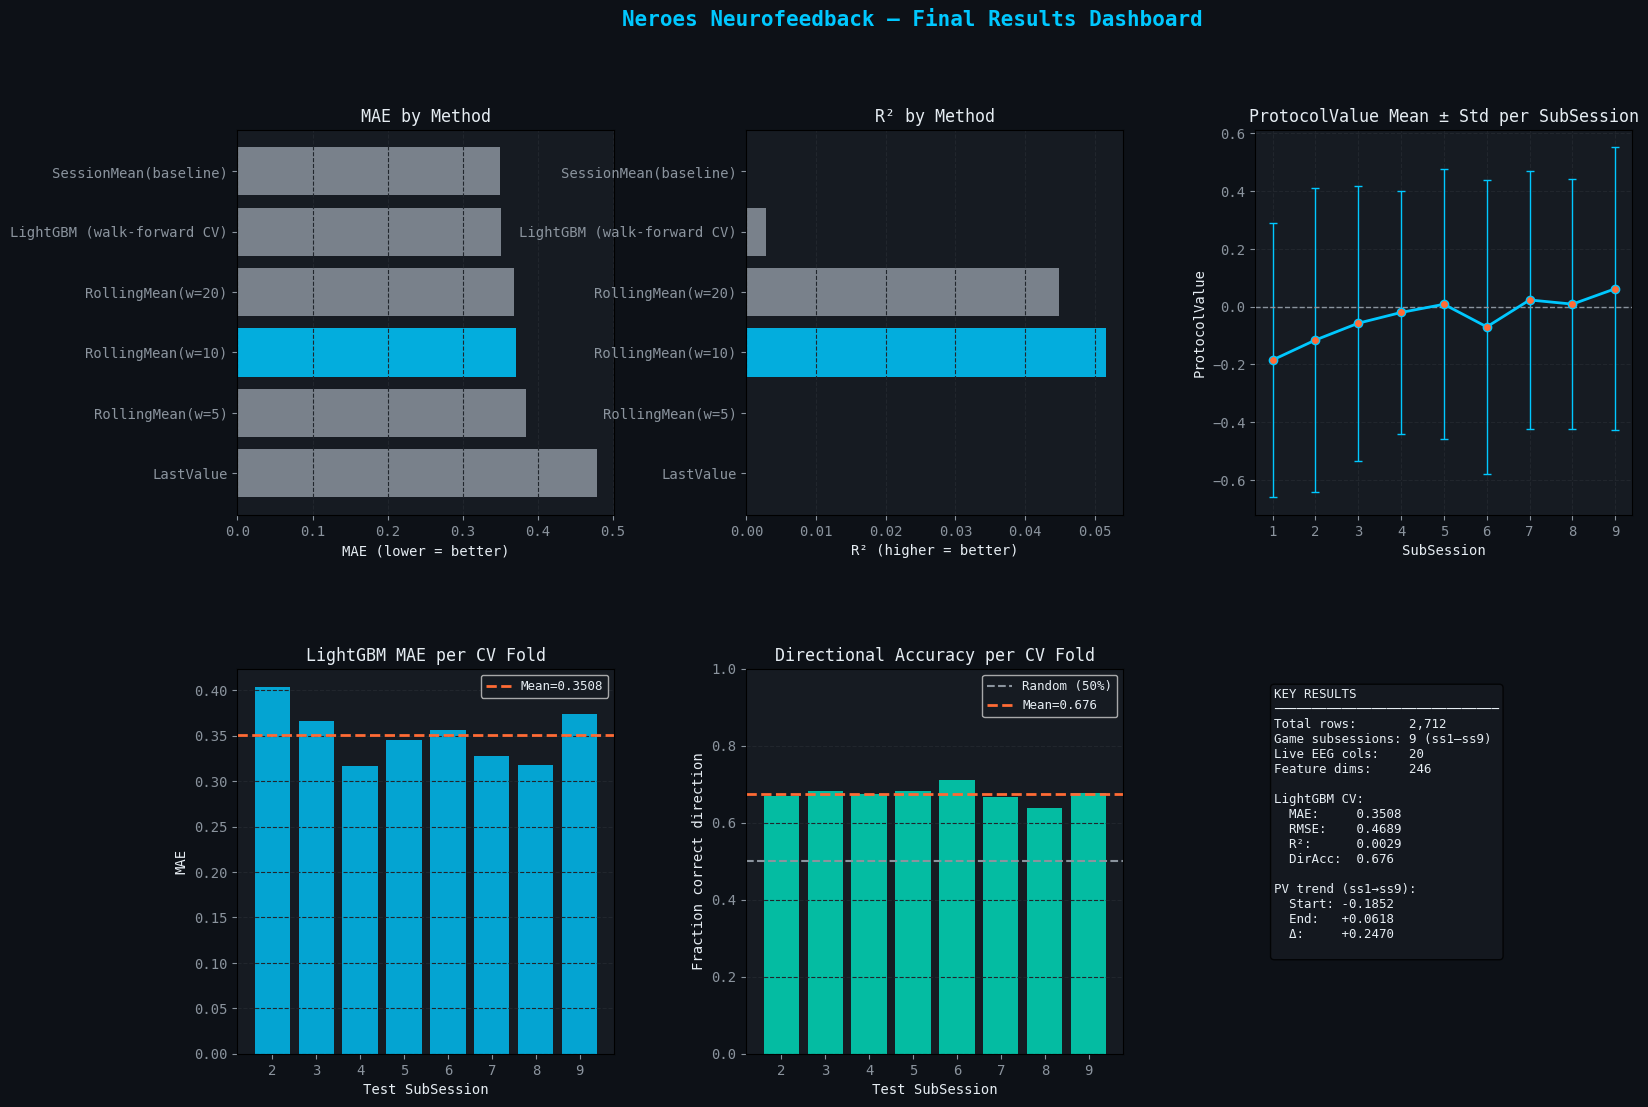

Saved: final_dashboard.png


In [4]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Neroes Neurofeedback — Final Results Dashboard',
             color='#00c8ff', fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: MAE comparison ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors_bar = ['#8b949e','#8b949e','#8b949e','#00c8ff']
bars = ax1.barh(prediction_table.index, prediction_table['MAE'],
                color=colors_bar[:len(prediction_table)], alpha=0.85)
ax1.set_title('MAE by Method', color='#e6edf3')
ax1.set_xlabel('MAE (lower = better)')
ax1.grid(True, axis='x')
ax1.invert_yaxis()
ax1.set_facecolor('#161b22')

# ── Panel 2: R² comparison ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.barh(prediction_table.index, prediction_table['R2'].clip(0),
         color=colors_bar[:len(prediction_table)], alpha=0.85)
ax2.set_title('R² by Method', color='#e6edf3')
ax2.set_xlabel('R² (higher = better)')
ax2.grid(True, axis='x')
ax2.invert_yaxis()
ax2.set_facecolor('#161b22')

# ── Panel 3: ProtocolValue trend across subsessions ───────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ss_means = df_game.groupby(SS_COL)[TARGET].mean()
ss_stds  = df_game.groupby(SS_COL)[TARGET].std()
ax3.errorbar(ss_means.index, ss_means.values, yerr=ss_stds.values,
             color='#00c8ff', lw=2, marker='o', capsize=3,
             markerfacecolor='#ff6b35', elinewidth=1)
ax3.axhline(0, color='#8b949e', lw=1, linestyle='--')
ax3.set_title('ProtocolValue Mean ± Std per SubSession', color='#e6edf3')
ax3.set_xlabel('SubSession')
ax3.set_ylabel('ProtocolValue')
ax3.grid(True)
ax3.set_facecolor('#161b22')

# ── Panel 4: CV MAE per fold ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.bar(cv_metrics['test_ss'], cv_metrics['MAE'], color='#00c8ff', alpha=0.8)
ax4.axhline(cv_metrics['MAE'].mean(), color='#ff6b35', lw=2, linestyle='--',
            label=f'Mean={cv_metrics["MAE"].mean():.4f}')
ax4.set_title('LightGBM MAE per CV Fold', color='#e6edf3')
ax4.set_xlabel('Test SubSession')
ax4.set_ylabel('MAE')
ax4.legend(fontsize=9)
ax4.grid(True, axis='y')
ax4.set_facecolor('#161b22')

# ── Panel 5: Directional accuracy ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(cv_metrics['test_ss'], cv_metrics['DirectionalAcc'],
        color='#00e5c3', alpha=0.8)
ax5.axhline(0.5, color='#8b949e', lw=1.5, linestyle='--', label='Random (50%)')
ax5.axhline(cv_metrics['DirectionalAcc'].mean(), color='#ff6b35', lw=2,
            linestyle='--', label=f'Mean={cv_metrics["DirectionalAcc"].mean():.3f}')
ax5.set_title('Directional Accuracy per CV Fold', color='#e6edf3')
ax5.set_xlabel('Test SubSession')
ax5.set_ylabel('Fraction correct direction')
ax5.legend(fontsize=9)
ax5.set_ylim(0, 1)
ax5.grid(True, axis='y')
ax5.set_facecolor('#161b22')

# ── Panel 6: Text summary ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary_text = (
    f"KEY RESULTS\n"
    f"{'─'*30}\n"
    f"Total rows:       {len(df_game):,}\n"
    f"Game subsessions: 9 (ss1–ss9)\n"
    f"Live EEG cols:    20\n"
    f"Feature dims:     {len(FEATURE_COLS)}\n"
    f"\n"
    f"LightGBM CV:\n"
    f"  MAE:     {cv_metrics['MAE'].mean():.4f}\n"
    f"  RMSE:    {cv_metrics['RMSE'].mean():.4f}\n"
    f"  R²:      {cv_metrics['R2'].mean():.4f}\n"
    f"  DirAcc:  {cv_metrics['DirectionalAcc'].mean():.3f}\n"
    f"\n"
    f"PV trend (ss1→ss9):\n"
    f"  Start: {ss_means.iloc[0]:+.4f}\n"
    f"  End:   {ss_means.iloc[-1]:+.4f}\n"
    f"  Δ:     {ss_means.iloc[-1]-ss_means.iloc[0]:+.4f}\n"
)
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=9, va='top', fontfamily='monospace',
         color='#e6edf3',
         bbox=dict(boxstyle='round', facecolor='#161b22', alpha=0.8))

plt.savefig('../outputs/figures/final_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: final_dashboard.png')

## 4. Final Summary Print

In [5]:
print('\n' + '═'*65)
print('  NEROES CHALLENGE — FINAL EVALUATION SUMMARY')
print('═'*65)
print()
print('PREDICTION MODULE (LightGBM, walk-forward CV):')
print(f'  MAE:              {cv_metrics["MAE"].mean():.4f} ± {cv_metrics["MAE"].std():.4f}')
print(f'  RMSE:             {cv_metrics["RMSE"].mean():.4f}')
print(f'  R²:               {cv_metrics["R2"].mean():.4f}')
print(f'  Directional Acc:  {cv_metrics["DirectionalAcc"].mean():.3f}')
print()
print('BASELINE COMPARISON:')
print(prediction_table[['MAE','R2']].round(5).to_string())
print()
print('RL AGENTS: see notebook 05 for IPS-estimated reward comparisons')
print()
print('NEUROFEEDBACK EFFICACY:')
trend = ss_means.iloc[-1] - ss_means.iloc[0]
print(f'  ProtocolValue improved by {trend:+.4f} from ss1 to ss9')
print(f'  (positive = user improved across sessions)')


═════════════════════════════════════════════════════════════════
  NEROES CHALLENGE — FINAL EVALUATION SUMMARY
═════════════════════════════════════════════════════════════════

PREDICTION MODULE (LightGBM, walk-forward CV):
  MAE:              0.3508 ± 0.0303
  RMSE:             0.4689
  R²:               0.0029
  Directional Acc:  0.676

BASELINE COMPARISON:
                                MAE       R2
SessionMean(baseline)       0.35013 -0.00000
LightGBM (walk-forward CV)  0.35081  0.00285
RollingMean(w=20)           0.36796  0.04493
RollingMean(w=10)           0.37180  0.05155
RollingMean(w=5)            0.38455 -0.04198
LastValue                   0.47851 -0.66676

RL AGENTS: see notebook 05 for IPS-estimated reward comparisons

NEUROFEEDBACK EFFICACY:
  ProtocolValue improved by +0.2470 from ss1 to ss9
  (positive = user improved across sessions)
